In [39]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import fetch_california_housing  
from sklearn.model_selection import GridSearchCV


In [40]:
data = fetch_california_housing()
X, y = data.data, data.target

In [41]:
X_train,X_test,y_train,y_test= train_test_split(X, y, test_size=0.2, random_state=42)


In [42]:
regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

DecisionTreeRegressor()

In [43]:
y_pred=regressor.predict(X_test)

In [44]:
r2_score(y_test,y_pred)

0.6134683978725889

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(1,10),
    'min_samples_split': range(2,10),
    'min_samples_leaf': range(1,10)
}

grid_search = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


Best parameters: {'max_depth': 9, 'min_samples_leaf': 8, 'min_samples_split': 8}


In [53]:
regressor = DecisionTreeRegressor(max_depth= 9, min_samples_leaf= 8, min_samples_split= 8)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=9, min_samples_leaf=8, min_samples_split=8)

In [54]:
y_pred=regressor.predict(X_test)

In [55]:
r2_score(y_test,y_pred)

0.7011594854633125

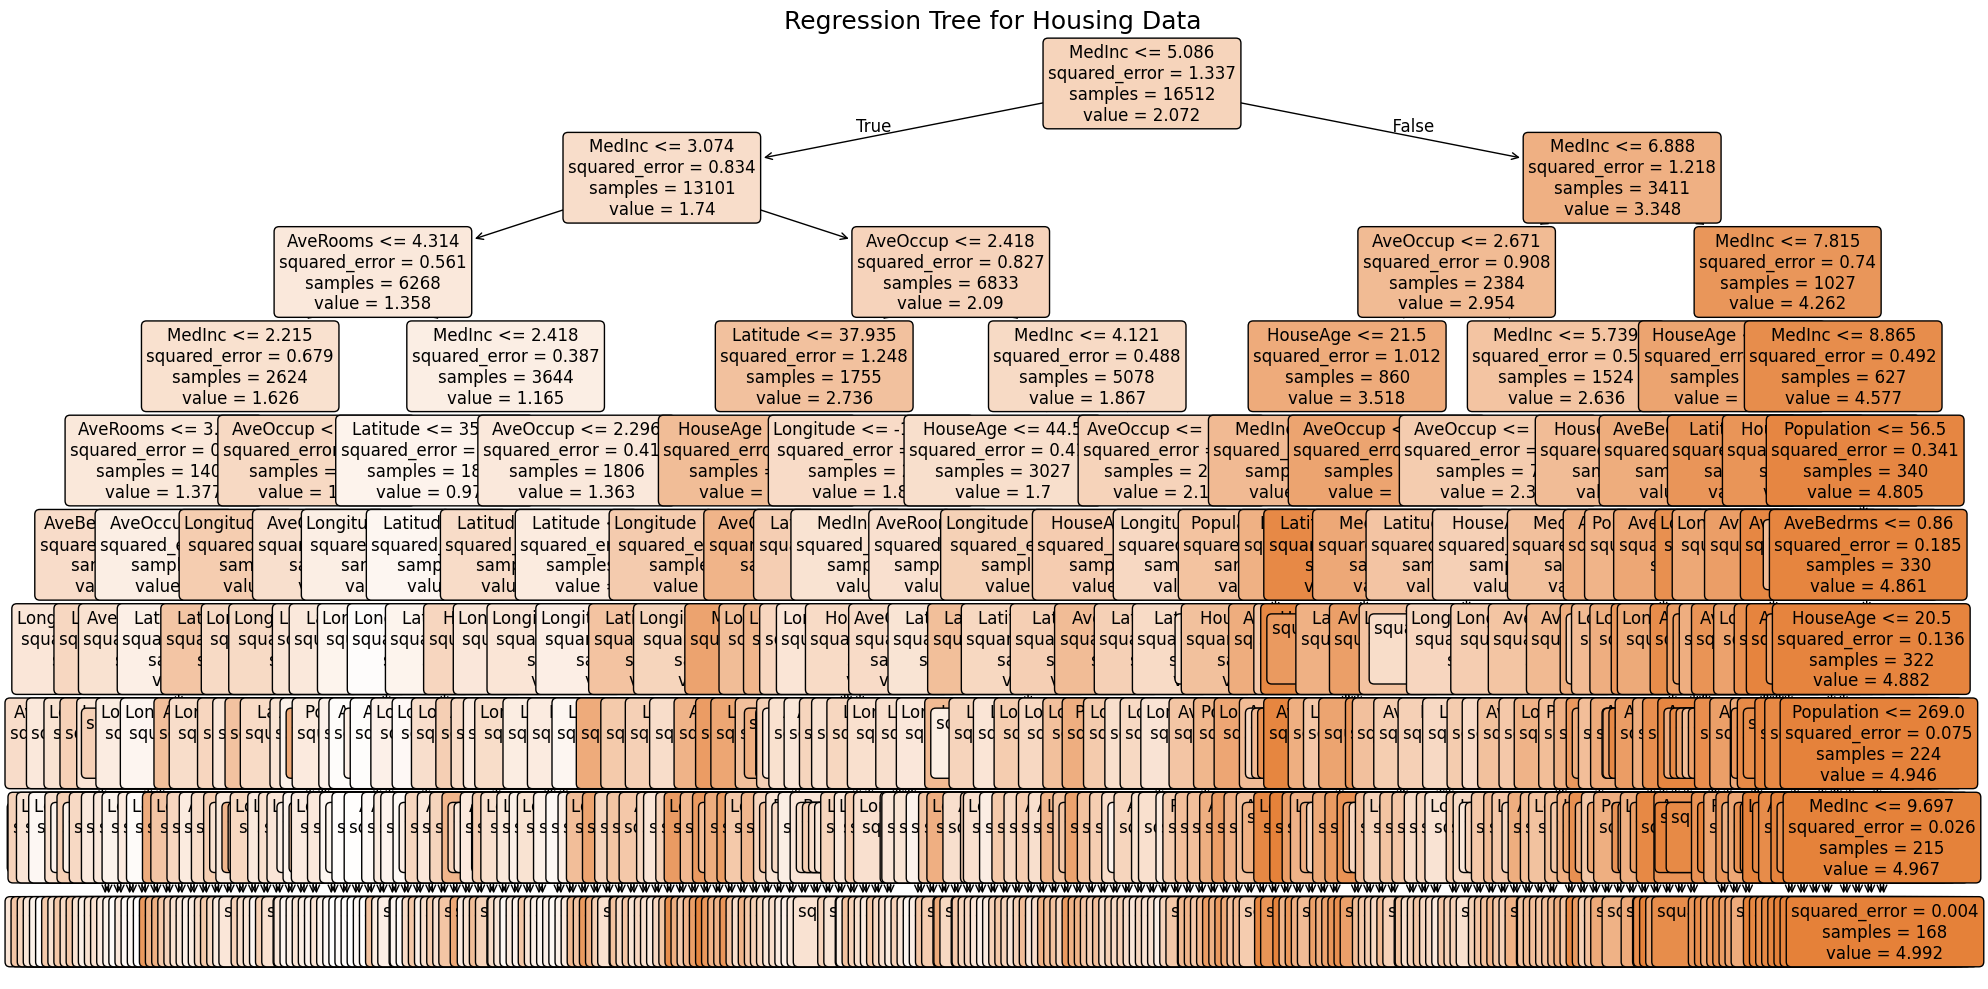

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.datasets import fetch_california_housing 

# Load dataset
data = fetch_california_housing()
feature_names = data.feature_names

plt.figure(figsize=(20, 10))
tree.plot_tree(regressor, feature_names=feature_names, 
              filled=True, rounded=True, fontsize=12)
plt.title("Regression Tree for Housing Data", fontsize=18)
plt.tight_layout()
plt.show()